# **Classificação**

Preparação dos dados
achando as features mais relevantes com metodo Embedded de RandomForest

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

breast = load_breast_cancer()
features = pd.DataFrame(breast["data"], columns=breast["feature_names"])
features = features + np.random.normal(0, 0.1, features.shape)  #ruido
target = pd.DataFrame(breast["target"])

scaler = MinMaxScaler()
X = pd.DataFrame(scaler.fit_transform(features), columns=breast["feature_names"])

#selecionando melhores features considerando que elas ja tão transformadas com scaler
embedded = RandomForestClassifier()
embedded.fit(X, target)
melhores_features = pd.DataFrame({
    "feature": breast.feature_names,
    "relevancia": embedded.feature_importances_
}).sort_values("relevancia", ascending=False).head(12)["feature"].values
melhores_features

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


array(['worst perimeter', 'worst radius', 'worst area', 'mean area',
       'area error', 'mean perimeter', 'mean radius', 'worst concavity',
       'mean texture', 'worst compactness', 'perimeter error',
       'worst texture'], dtype=object)

Ao fazer o pairplot das melhores features selecionadas, vemos varias relações lineares e classes bem divididas, porem o ruido e o standard scaler afetam ligeiramente a distribuição.

<ipython-input-2-05f27082eb92>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_features["target"] = breast["target"]


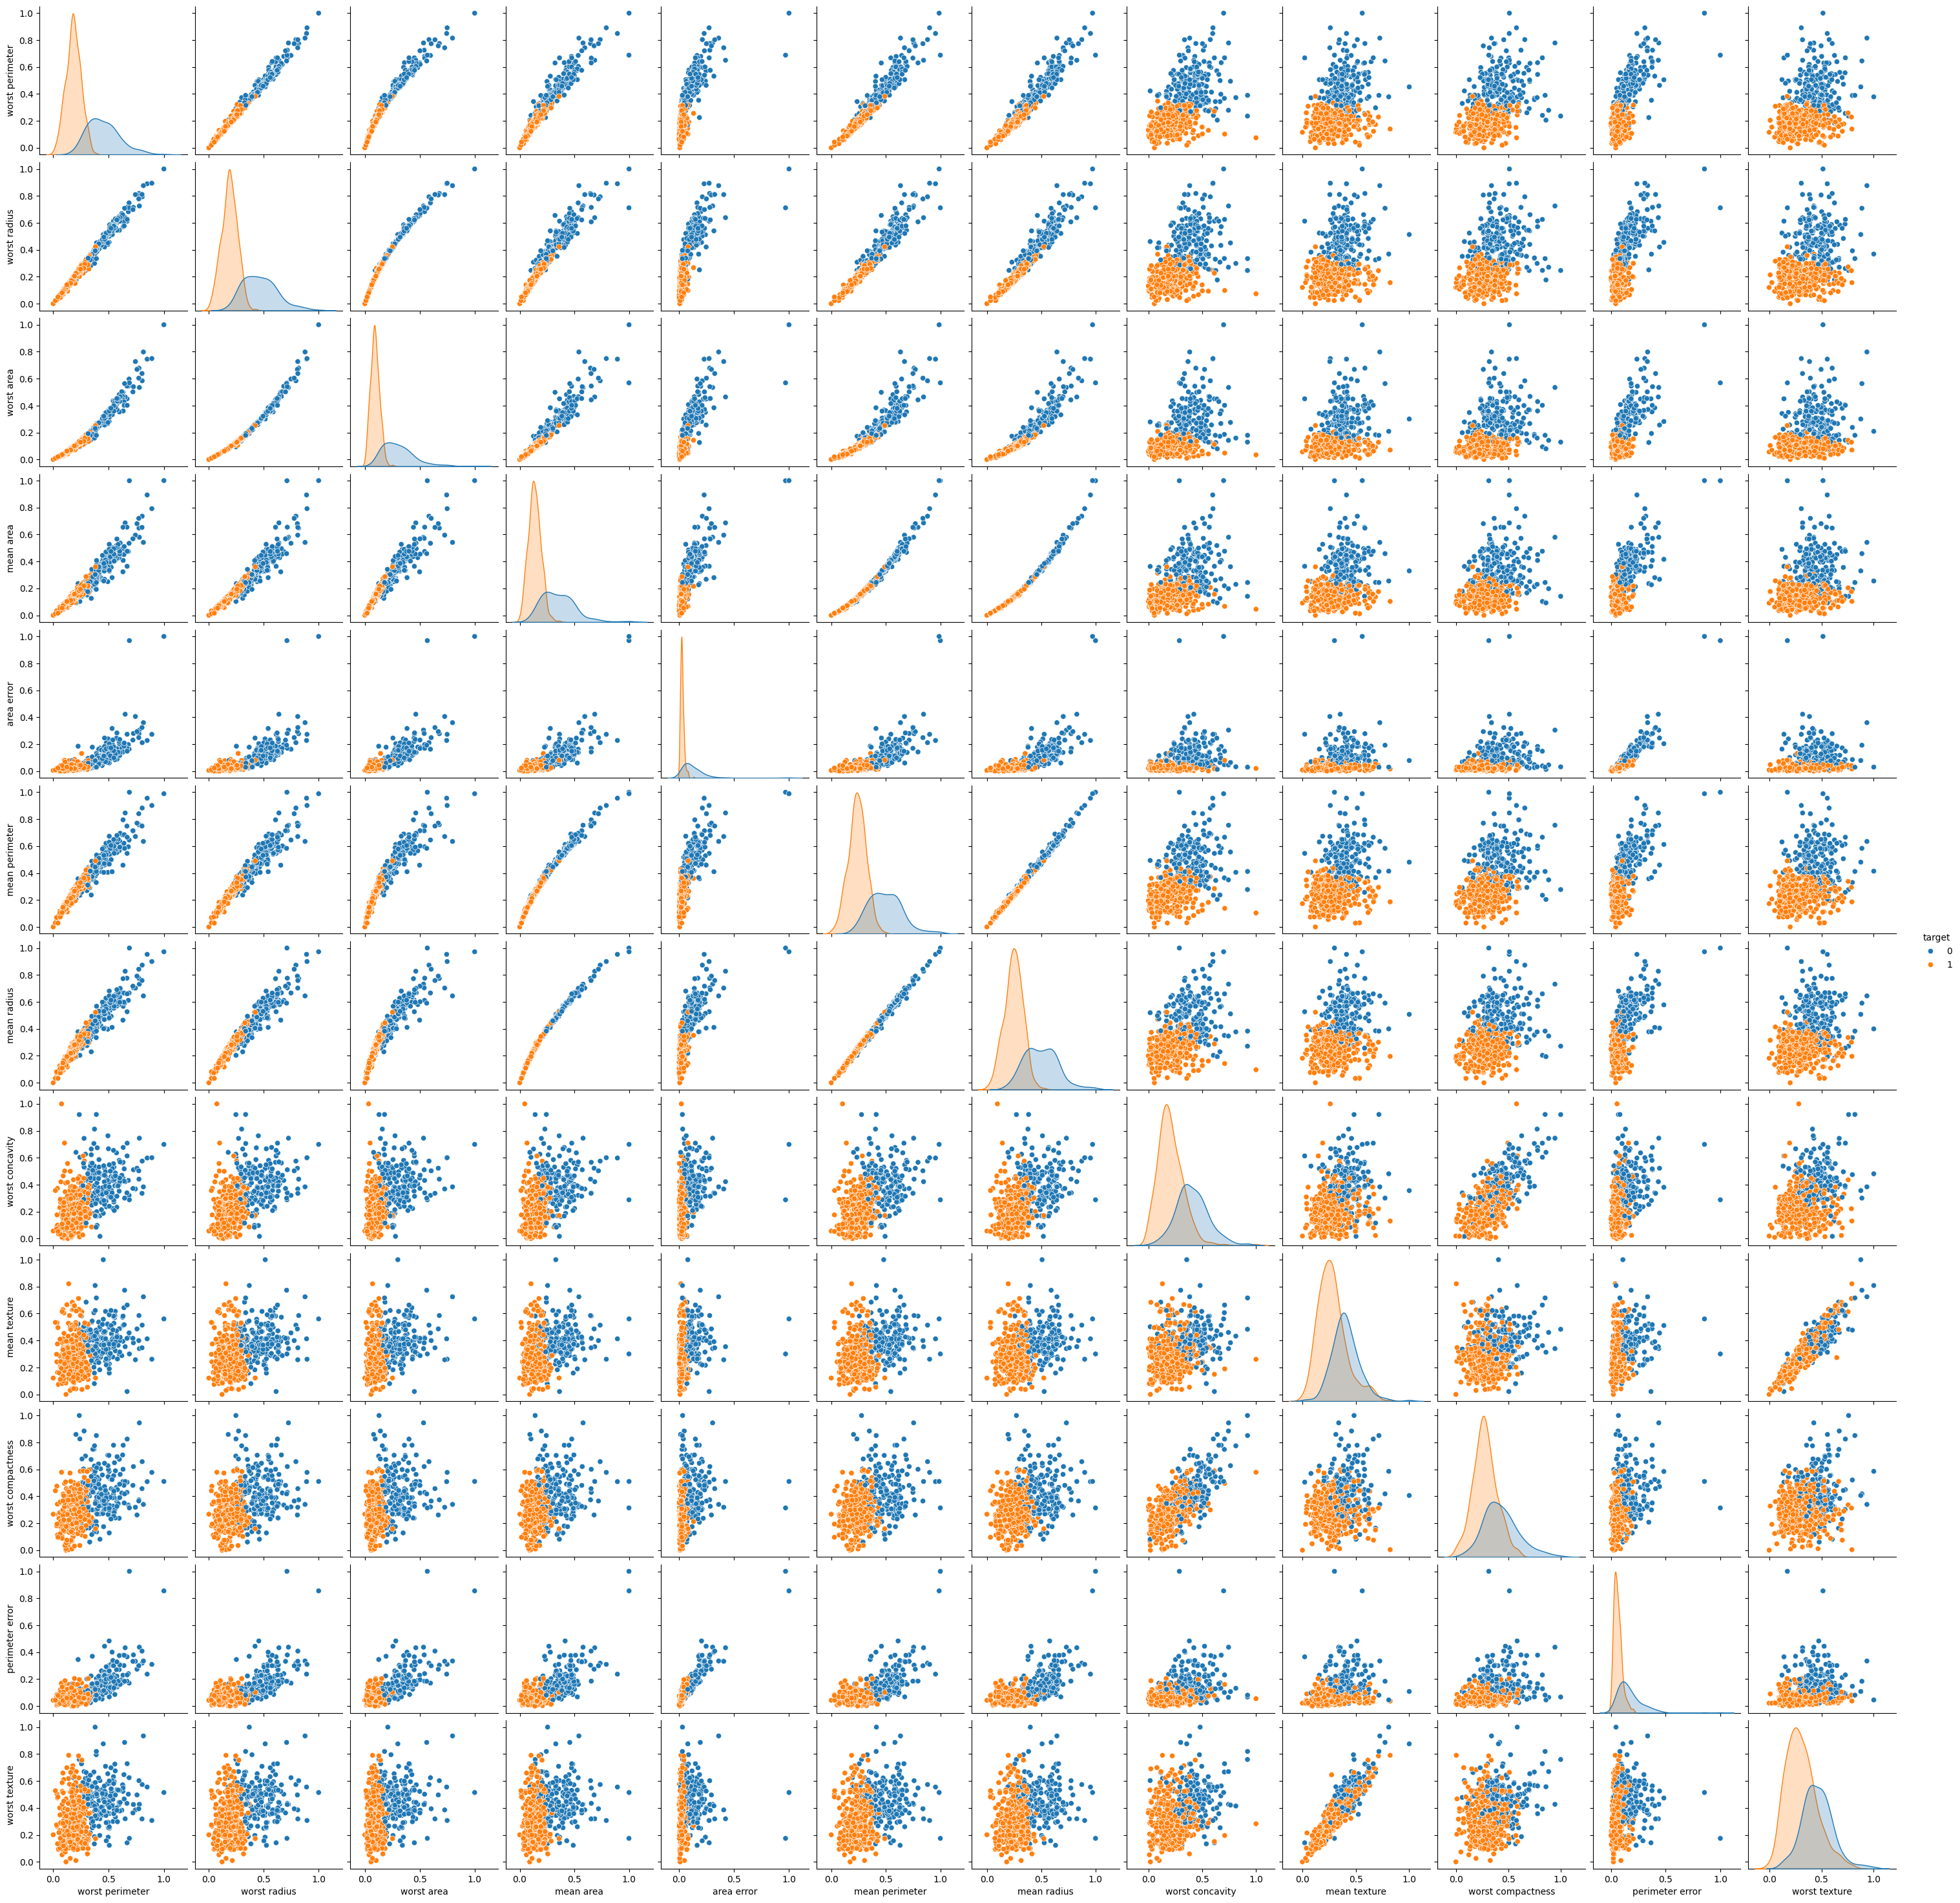

In [ ]:
import seaborn as sns
plot_features = X[melhores_features]
plot_features["target"] = breast["target"]
sns.pairplot(plot_features, hue="target")

Criação do melhor classificador KNN com GridSearchCV

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

X = X[melhores_features]
y = target

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'n_neighbors': range(3, 25, 1),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

for cv_val in [2, 4, 5, 6]:
  knn = KNeighborsClassifier()

  grid_search = GridSearchCV(
      estimator=knn,
      param_grid=param_grid,
      cv=cv_val,
      scoring='accuracy',
      n_jobs=-1
  )

  grid_search.fit(X_train, y_train)

  print(cv_val, "\n" , grid_search.best_params_)

  pred = grid_search.predict(X_val)
  acuracia = accuracy_score(y_val, pred)
  print(f"Acuracia: {acuracia}")

  best_knn = grid_search.best_estimator_
  print(best_knn)

/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


2 
 {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'uniform'}
Acuracia: 0.9649122807017544
KNeighborsClassifier(metric='manhattan', n_neighbors=6)


/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


4 
 {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'uniform'}
Acuracia: 0.9649122807017544
KNeighborsClassifier(metric='manhattan', n_neighbors=4)


/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


5 
 {'metric': 'euclidean', 'n_neighbors': 6, 'weights': 'uniform'}
Acuracia: 0.956140350877193
KNeighborsClassifier(metric='euclidean', n_neighbors=6)
6 
 {'metric': 'euclidean', 'n_neighbors': 14, 'weights': 'uniform'}
Acuracia: 0.956140350877193
KNeighborsClassifier(metric='euclidean', n_neighbors=14)


/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Teste

In [ ]:
from sklearn.metrics import confusion_matrix

features = pd.DataFrame(breast["data"], columns=breast["feature_names"]) #tirando o ruido
X = features[melhores_features]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
best_knn = KNeighborsClassifier(metric="euclidean", n_neighbors=6, weights="uniform")

best_knn.fit(X_train, y_train)
pred = best_knn.predict(X_test)
acuracia = accuracy_score(y_test, pred)
print(f"Acuracia: {acuracia}")

Acuracia: 0.9649122807017544


/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Graficos

Text(50.722222222222214, 0.5, 'Teste')

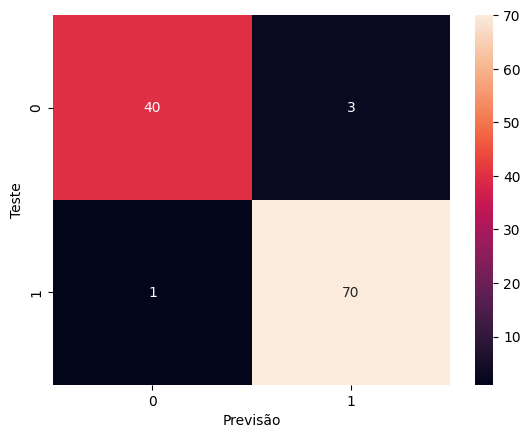

In [ ]:
ax = sns.heatmap(confusion_matrix(y_test, pred), annot=True)
ax.set_xlabel('Previsão')
ax.set_ylabel('Teste')

# **Regressão**

Preparação dos dados
achando as features mais relevantes com metodo wrapper (RFE) e estimador LinearRegression

In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

breast = load_breast_cancer()
features = pd.DataFrame(breast["data"], columns=breast["feature_names"])
target = features["mean area"]
features = features.drop("mean area", axis=1)
features = features + np.random.normal(0, 0.1, features.shape)  #ruido
features["target"] = breast["target"]

scaler = MinMaxScaler()
X = pd.DataFrame(scaler.fit_transform(features), columns=breast["feature_names"])

model = LinearRegression()
rfe = RFE(estimator=model, n_features_to_select=12)
fit = rfe.fit(X, target)
melhores_features = features.columns[fit.support_]
print(melhores_features)

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean compactness',
       'texture error', 'perimeter error', 'area error', 'worst radius',
       'worst texture', 'worst perimeter', 'worst area', 'worst compactness'],
      dtype='object')


Criação do melhor modelo de ElasticNet com GridSearchCV

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score

X = X[melhores_features]
y = target

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10, 100],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]
}

for cv_val in [2, 4, 5, 6]:
  elastic = ElasticNet()

  grid_search = GridSearchCV(
      estimator=elastic,
      param_grid=param_grid,
      cv=cv_val,
      scoring='r2',
      n_jobs=-1
  )

  grid_search.fit(X_train, y_train)

  print(cv_val, "\n" , grid_search.best_params_)

  pred = grid_search.predict(X_val)
  r2 = r2_score(y_val, pred)
  print(f"R2: {r2}")

  best_elastic = grid_search.best_estimator_
  print(best_elastic)

2 
 {'alpha': 0.001, 'l1_ratio': 0.95}
R2: 0.9912753093474727
ElasticNet(alpha=0.001, l1_ratio=0.95)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.744e+04, tolerance: 5.720e+03
  model = cd_fast.enet_coordinate_descent(


4 
 {'alpha': 0.01, 'l1_ratio': 1.0}
R2: 0.9910737286259379
ElasticNet(alpha=0.01, l1_ratio=1.0)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.744e+04, tolerance: 5.720e+03
  model = cd_fast.enet_coordinate_descent(


5 
 {'alpha': 0.01, 'l1_ratio': 1.0}
R2: 0.9910737286259379
ElasticNet(alpha=0.01, l1_ratio=1.0)
6 
 {'alpha': 0.01, 'l1_ratio': 1.0}
R2: 0.9910737286259379
ElasticNet(alpha=0.01, l1_ratio=1.0)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.744e+04, tolerance: 5.720e+03
  model = cd_fast.enet_coordinate_descent(


Teste

In [ ]:
import seaborn as sns
from scipy.stats import skew, kurtosis, shapiro, normaltest
from sklearn.metrics import mean_absolute_error, mean_squared_error

features = pd.DataFrame(breast["data"], columns=breast["feature_names"]) #tirando o ruido
features["target"] = breast["target"]
X = features[melhores_features]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_elastic = ElasticNet( alpha=0.01, l1_ratio = 1.0 )

best_elastic.fit(X_train, y_train)


pred = best_elastic.predict(X_test)
r2 = r2_score(y_test, pred)
print(f"R2: {r2}")


R2: 0.9943635276762258


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.407e+04, tolerance: 5.720e+03
  model = cd_fast.enet_coordinate_descent(


Graficos e Estatisticas

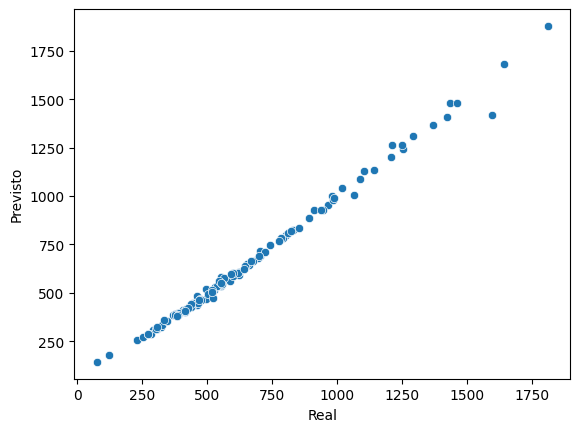

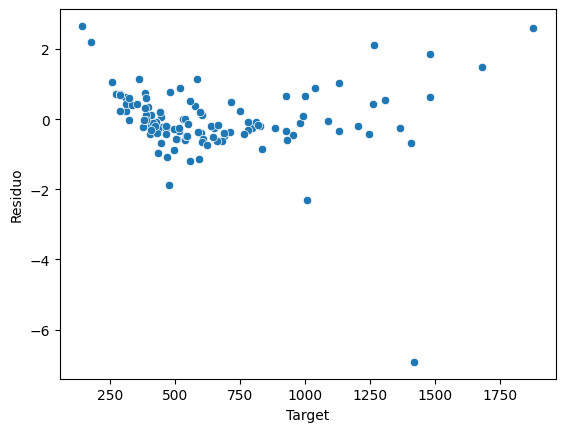

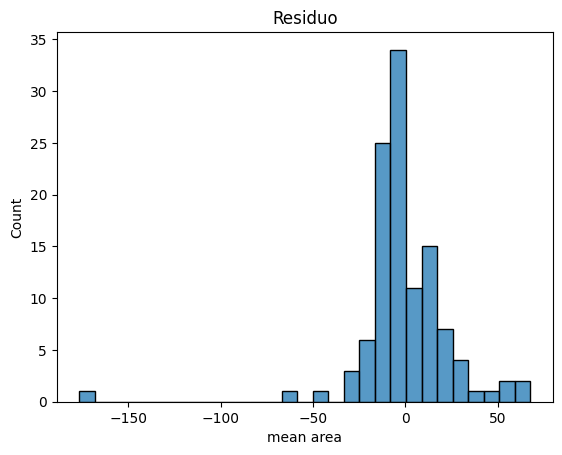

Estatisticas do residuo:
 {'Média': np.float64(-0.952634512653805)
 'Mediana': np.float64(-4.091078769716347)
 'Desvio Padrão': 25.4763091645712
 'Variância': 649.0423286488145
 'Mínimo': -176.3931250224714
 'Máximo': 67.7552240788491
 'Intervalo': np.float64(244.1483491013205)
 'Assimetria': np.float64(-2.3793046804709896)
 'Curtose': np.float64(18.69921942280597)
 'MAE': 15.46196159395902
 'MSE': 649.9498411635136
 'RMSE': np.float64(25.4941138532704)}


In [ ]:

sns.scatterplot(x=pred, y=y_test)
plt.xlabel("Real")
plt.ylabel("Previsto")
plt.show()
residual_normal = (y_test - pred) / np.std(y_test - pred)
sns.scatterplot(x=y_test, y=residual_normal)
plt.xlabel("Target")
plt.ylabel("Residuo")
plt.show()


residuos = y_test - pred
sns.histplot(y_test-pred)
plt.title("Residuo")
plt.show()
stats_residuos = {
    'Média': np.mean(residuos),
    'Mediana': np.median(residuos),
    'Desvio Padrão': np.std(residuos),
    'Variância': np.var(residuos),
    'Mínimo': np.min(residuos),
    'Máximo': np.max(residuos),
    'Intervalo': np.ptp(residuos),
    'Assimetria': skew(residuos),
    'Curtose': kurtosis(residuos),
    'MAE': mean_absolute_error(y_test, pred),
    'MSE': mean_squared_error(y_test, pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, pred))
}

print("Estatisticas do residuo:\n", str(stats_residuos).replace(",", "\n"))